<a href="https://colab.research.google.com/github/jaipriyap6-code/codsoft_tasks/blob/main/CODSOFT_Task5_Web_Data_Extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install requests beautifulsoup4

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Connect to a public website

In [ ]:
url = "https://books.toscrape.com/"
response = requests.get(url)
print(response.status_code)

200


Read the webpage

In [ ]:
soup = BeautifulSoup(response.text, "html.parser")

book information

In [ ]:
books = soup.find_all("h3")
for book in books:
    print(book.a["title"])

A Light in the Attic
Tipping the Velvet
Soumission
Sharp Objects
Sapiens: A Brief History of Humankind
The Requiem Red
The Dirty Little Secrets of Getting Your Dream Job
The Coming Woman: A Novel Based on the Life of the Infamous Feminist, Victoria Woodhull
The Boys in the Boat: Nine Americans and Their Epic Quest for Gold at the 1936 Berlin Olympics
The Black Maria
Starving Hearts (Triangular Trade Trilogy, #1)
Shakespeare's Sonnets
Set Me Free
Scott Pilgrim's Precious Little Life (Scott Pilgrim #1)
Rip it Up and Start Again
Our Band Could Be Your Life: Scenes from the American Indie Underground, 1981-1991
Olio
Mesaerion: The Best Science Fiction Stories 1800-1849
Libertarianism for Beginners
It's Only the Himalayas


Title, Price, and Rating

In [ ]:
books_data = []
for book in soup.select("article.product_pod"):
    title = book.h3.a["title"]
    price = book.select_one(".price_color").text
    rating = book.select_one("p.star-rating")["class"][1]
books_data.append([title, price, rating])

In [ ]:
df.shape

(40, 3)

create dataframe

In [ ]:
df = pd.DataFrame(
    books_data,
    columns=["Title", "Price", "Rating"])
df.head()

,Title,Price,Rating
0,It's Only the Himalayas,Â£45.17,Two


Check how many books we collected

In [ ]:
books_data = []

books = soup.find_all("article", class_="product_pod")

print("Number of books:", len(books))

Number of books: 20


In [ ]:
df = pd.DataFrame(
    books_data,
    columns=["Title", "Price", "Rating"]
)

In [ ]:
print("Number of books:", len(books))

Number of books: 20


In [ ]:
df['Price'] = df['Price'].str.replace('Â£', '').astype(float)

In [ ]:
rating_map = {
    'One': 1,
    'Two': 2,
    'Three': 3,
    'Four': 4,
    'Five': 5
}

df['Rating'] = df['Rating'].map(rating_map)

In [ ]:
df.head()

,Title,Price,Rating
0,A Light in the Attic,51.77,3
1,Tipping the Velvet,53.74,1
2,Soumission,50.10,1
3,Sharp Objects,47.82,4
4,Sapiens: A Brief History of Humankind,54.23,5


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Title   40 non-null     object 
 1   Price   40 non-null     float64
 2   Rating  40 non-null     int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ KB


In [ ]:
df['Price'].mean()

np.float64(38.048500000000004)

In [ ]:
df['Price'].max()

57.25

In [ ]:
df['Price'].min()

13.99

In [ ]:
df['Rating'].mean()

np.float64(2.85)

In [ ]:
df.sort_values('Price', ascending=False).head(5)

,Title,Price,Rating
35,Our Band Could Be Your Life: Scenes from the A...,57.25,3
15,Our Band Could Be Your Life: Scenes from the A...,57.25,3
4,Sapiens: A Brief History of Humankind,54.23,5
24,Sapiens: A Brief History of Humankind,54.23,5
21,Tipping the Velvet,53.74,1


In [ ]:
df.sort_values('Rating', ascending=False).head(5)

,Title,Price,Rating
4,Sapiens: A Brief History of Humankind,54.23,5
34,Rip it Up and Start Again,35.02,5
33,Scott Pilgrim's Precious Little Life (Scott Pi...,52.29,5
32,Set Me Free,17.46,5
24,Sapiens: A Brief History of Humankind,54.23,5


In [ ]:
base_url = "http://books.toscrape.com/catalogue/page-{}.html"
data = []
# Scrape first 3 pages
for page in range(1, 4):
    res = requests.get(base_url.format(page))
    if res.status_code == 200:
        soup = BeautifulSoup(res.text, "html.parser")
        for item in soup.find_all("article", class_="product_pod"):
            title = item.h3.a["title"]
            price = item.find("p", class_="price_color").text
            rating = item.p["class"][1]
            data.append({"Title": title, "Price": price, "Rating": rating})
# Export raw dataset
df = pd.DataFrame(data)
df.to_csv("raw_books.csv", index=False)
print("Scraping complete! Saved to raw_books.csv")


Scraping complete! Saved to raw_books.csv


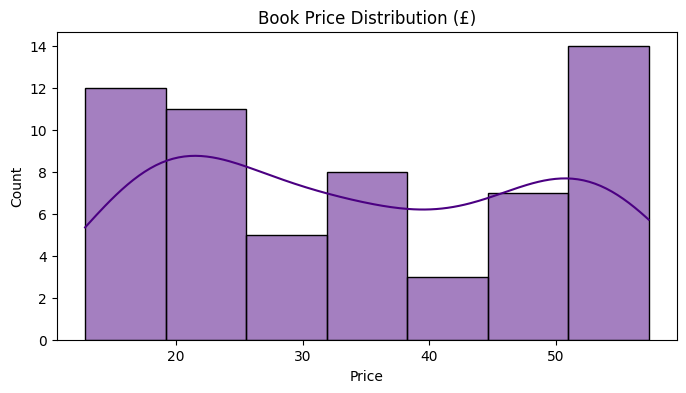

In [ ]:
df = pd.read_csv("raw_books.csv")
# Clean price data & map ratings
df["Price_GBP"] = df["Price"].str.replace("Â£", "").astype(float)
rating_map = {"One": 1, "Two": 2, "Three": 3, "Four": 4, "Five": 5}
df["Rating_Num"] = df["Rating"].map(rating_map)
# Save cleaned output
df.to_csv("cleaned_books.csv", index=False)
# Quick EDA Chart
plt.figure(figsize=(8, 4))
sns.histplot(df["Price_GBP"], kde=True, color="indigo")
plt.title("Book Price Distribution (£)")
plt.xlabel("Price")
plt.savefig("price_chart.png")
plt.show()
